In [29]:
!pip install xgboost
!pip install catboost
!pip install shap

In [30]:
import os
import numpy as np
import pandas as pd
import xgboost as xgb
import catboost as cb
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error



In [31]:
data = pd.read_csv('data.csv')
data.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
selected_features = ['TransactionAmt', 'isFraud', 'card1','C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1']
data = data[selected_features]

In [33]:
# разобъем данные для вывода качества модели, axis=1 указывает методу drop(pd), что удаляемый объект столбец
# random_state=1 обеспечивает повторяемость случайных процессов
x_train, x_valid = train_test_split(
    data.drop(['isFraud'], axis=1), train_size=0.7,random_state=1 
)
y_train, y_valid = train_test_split(
    data['isFraud'], train_size=0.7, random_state=1
)

**1.Обучение базовой модели XGBoost(sklearn-API)** . Прогнозирование вероятности совершения транзакций клиентом банка

In [34]:
# обучение модели с базовыми параметрами
baseline = xgb.XGBClassifier(random_state=27)
baseline.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [35]:
# Прогнозирование модели и оценка модели с помощью метрики качества
y_pred = baseline.predict_proba(x_valid) # возвращает вероятности принадлежности каждого объекта к классу в виде массива numpy
score = roc_auc_score(y_valid, y_pred[:, 1]) # индексация массива numpy, вероятность положит класса
print(f'score = {round(score, 4)}')

score = 0.9128


**Обучение модели XGBoost с использованием оригинального API**

In [36]:
xgb_params = {
    'booster': 'gbtree',
    'objective': 'binary:logistic',
    'eval_metric': 'auc', # оптимизируем модель по площади под ROC-кривой
    'learning_rate': 0.1, # консерв темп обучения(меньше риска переобучения)
    'reg_lambda': 100,
    'max_depth': 4,
    'nthread': 6, # кол-во потоков для паралелл вычислений
    'gamma': 10, # мин уменьшение loss для дальнейшего разбиения листа дерева
    'seed': 27
}
# спец внутр формат данных для xgb
dtrain = xgb.DMatrix(
    data=x_train, label=y_train 
)
dvalid = xgb.DMatrix(
    data=x_valid, label=y_valid
)

In [37]:
evals_result = {}

model = xgb.train(
    params=xgb_params,
    dtrain=dtrain, # обучающие данные в формате DMatrix
    num_boost_round=1000, # максим кол-во деревьев
    maximize=True, # метрика качества auc должна быть максимизирована
    early_stopping_rounds=50, # если после 50 последов итераций качество на валидац выборке не улучш-ся, обучение прекращ-ся,это предотвр-ет переобучение
    evals_result=evals_result,
    evals=[(dtrain, 'train'), (dvalid, 'valid')], # список кортежей для оценки метрики в процессе обучения, сохраняться в evals_result
    verbose_eval=25 # каждые 25 итераций в консоль будет выводиться инфор-ция о текущих значениях метрик
)

[0]	train-auc:0.77713	valid-auc:0.77230
[25]	train-auc:0.85659	valid-auc:0.84850
[50]	train-auc:0.86969	valid-auc:0.85809
[75]	train-auc:0.87026	valid-auc:0.85848
[100]	train-auc:0.87026	valid-auc:0.85848
[123]	train-auc:0.87026	valid-auc:0.85848


Text(0, 0.5, 'ROC_AUC')

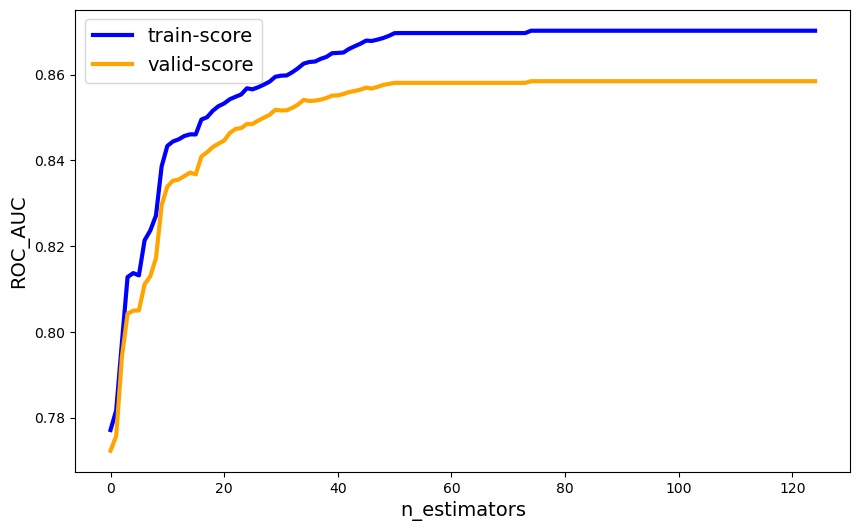

In [38]:
fig = plt.figure(figsize=(10, 6))
plt.plot(evals_result['train']['auc'], linewidth=3, label='train-score', color='blue')
plt.plot(evals_result['valid']['auc'], linewidth=3, label='valid-score', color='orange')
plt.legend(loc='best', fontsize=14) # автоматически выберет наилучшее расположение легенды на графике
plt.xlabel('n_estimators', size=14)
plt.ylabel('ROC_AUC', size=14)

In [39]:
cv_score = xgb.cv(
    dtrain=dtrain,
    params=xgb_params,
    num_boost_round=1000,
    early_stopping_rounds=50,
    verbose_eval=25, # периодичность вывода результатов(каждые 25 раундов)
    maximize=True,
    nfold=3 # кол-во фолдов разбиений для кросс-валидации
)

[0]	train-auc:0.77358+0.00367	test-auc:0.76448+0.01557
[25]	train-auc:0.85572+0.00135	test-auc:0.84733+0.00545
[50]	train-auc:0.86611+0.00156	test-auc:0.85814+0.00621
[75]	train-auc:0.86637+0.00146	test-auc:0.85857+0.00643
[100]	train-auc:0.86637+0.00146	test-auc:0.85857+0.00643
[114]	train-auc:0.86637+0.00146	test-auc:0.85857+0.00643


Text(0, 0.5, 'ROC-AUC')

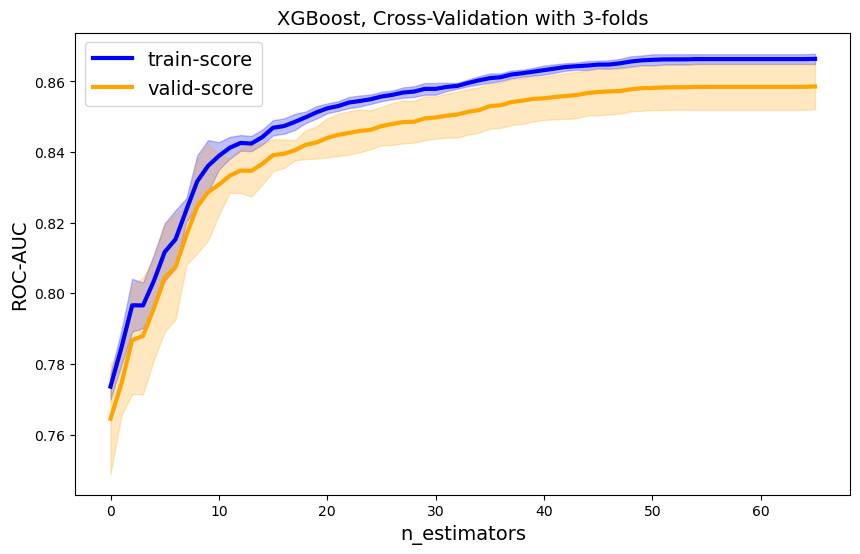

In [40]:
# создает визуализацию результатов кросс-валидации XGBoost
fig = plt.figure(figsize=(10, 6))
plt.title('XGBoost, Cross-Validation with 3-folds', size=14)
plt.plot(
    cv_score['train-auc-mean'],
    label='train-score',
    linewidth=3,
    color='blue'
)
# создает область вокруг линии, показывающая разброс значений(+/- стандартное отклонение )
plt.fill_between(
    x=range(cv_score.shape[0]), # по оси X - номера итераций
    y1=cv_score['train-auc-mean']-cv_score['train-auc-std'], # нижняя граница
    y2=cv_score['train-auc-mean']+cv_score['train-auc-std'], # верхняя граница
    color='blue', alpha=0.25 # прозрачность заливки
)
plt.plot(
    cv_score['test-auc-mean'],
    label='valid-score',
    color='orange',
    linewidth=3
)
plt.fill_between(
    x=range(cv_score.shape[0]),
    y1=cv_score['test-auc-mean']-cv_score['test-auc-std'],
    y2=cv_score['test-auc-mean']+cv_score['test-auc-std'],
    color='orange', alpha=0.25
)
plt.legend(loc='best', fontsize=14)
plt.xlabel('n_estimators', size=14)
plt.ylabel('ROC-AUC', size=14)

**2.Обучение базовой модели CatBoost**

In [41]:
model = cb.CatBoostClassifier(random_state=27)
model.fit(x_train, y_train)

Learning rate set to 0.063211
0:	learn: 0.5862561	total: 24.9ms	remaining: 24.9s
1:	learn: 0.4966476	total: 36.8ms	remaining: 18.4s
2:	learn: 0.4241390	total: 50.6ms	remaining: 16.8s
3:	learn: 0.3657505	total: 64.4ms	remaining: 16s
4:	learn: 0.3201338	total: 77ms	remaining: 15.3s
5:	learn: 0.2822190	total: 88.4ms	remaining: 14.6s
6:	learn: 0.2538220	total: 106ms	remaining: 15.1s
7:	learn: 0.2285392	total: 119ms	remaining: 14.8s
8:	learn: 0.2058343	total: 132ms	remaining: 14.6s
9:	learn: 0.1871970	total: 149ms	remaining: 14.8s
10:	learn: 0.1725764	total: 163ms	remaining: 14.6s
11:	learn: 0.1598040	total: 177ms	remaining: 14.6s
12:	learn: 0.1498144	total: 193ms	remaining: 14.6s
13:	learn: 0.1413867	total: 209ms	remaining: 14.7s
14:	learn: 0.1347761	total: 221ms	remaining: 14.5s
15:	learn: 0.1282776	total: 235ms	remaining: 14.5s
16:	learn: 0.1226936	total: 249ms	remaining: 14.4s
17:	learn: 0.1192719	total: 262ms	remaining: 14.3s
18:	learn: 0.1161439	total: 275ms	remaining: 14.2s
19:	learn

In [42]:
y_pred = model.predict_proba(x_valid)
score = roc_auc_score(y_valid, y_pred[:, 1])
print(f'score = {round(score, 4)}')

score = 0.9014


In [43]:
cb_params = {
    'n_estimators': 5000,
    'learning_rate': 0.01,
    'loss_function': 'Logloss', # функция потерь, которая будет оптимиз-ся
    'eval_metric': 'AUC',
    'task_type': 'CPU', # вычисления будут производиться на CPU(центр процессор для малых объемов данных) 
    'verbose': 50, # частота вывода информации в процессе обучения
    'max_depth': 6, # ограничение глубины помогает бороться с переобучением
    'l2_leaf_reg': 10, # коэфф l2
    'early_stopping_rounds': 50, # кол-во итераций после которых обучение останов-ся,если качество на валидац выборке не улучш-ся
    'thread_count': 6, # кол-во ядер процессора для паралл вычислений
    'random_seed': 42 # генератор случайных чисел для воспроизв резул-ов
}
# если бы категор признаки были, нужно было бы передать список индексов категор признаков
# спец структура данных cb.Pool в catboost для эффект хранения и обработки данных
cb_train = cb.Pool(
    data=x_train, label=y_train, cat_features=None
    
)
cb_valid = cb.Pool(
    data=x_valid, label=y_valid, cat_features=None
)

In [44]:
model = cb.train(
    params=cb_params,
    dtrain=cb_train,
    eval_set=[cb_train, cb_valid], # список данных для оценки качества модели во время обучения
    plot=True # визуализирует процесс обучения в реальном времени,значение метрики eval_metric=AUC на обучающ данных и валидац данных,как изменяется качество с каждой итерацией обучения
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	test: 0.5819236	test1: 0.5957191	best: 0.5957191 (0)	total: 19.1ms	remaining: 1m 35s
50:	test: 0.7731002	test1: 0.7567984	best: 0.7567984 (50)	total: 1.02s	remaining: 1m 39s
100:	test: 0.8269765	test1: 0.8130616	best: 0.8130616 (100)	total: 1.98s	remaining: 1m 36s
150:	test: 0.8394533	test1: 0.8269964	best: 0.8271397 (149)	total: 3.01s	remaining: 1m 36s
200:	test: 0.8460828	test1: 0.8335965	best: 0.8335965 (200)	total: 4.01s	remaining: 1m 35s
250:	test: 0.8553854	test1: 0.8425725	best: 0.8425725 (250)	total: 4.96s	remaining: 1m 33s
300:	test: 0.8613328	test1: 0.8485857	best: 0.8485857 (300)	total: 5.92s	remaining: 1m 32s
350:	test: 0.8651729	test1: 0.8520279	best: 0.8520279 (350)	total: 6.91s	remaining: 1m 31s
400:	test: 0.8689767	test1: 0.8554789	best: 0.8554789 (400)	total: 7.99s	remaining: 1m 31s
450:	test: 0.8725262	test1: 0.8580608	best: 0.8580608 (450)	total: 8.98s	remaining: 1m 30s
500:	test: 0.8758646	test1: 0.8603954	best: 0.8604146 (499)	total: 9.96s	remaining: 1m 29s
550:

In [45]:
catboost_cv = cb.cv(
    pool=cb_train,
    params=cb_params,
    plot=True,
    nfold=3,
    seed=27
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Training on fold [0/3]
0:	test: 0.6211262	best: 0.6211262 (0)	total: 16.8ms	remaining: 1m 23s
50:	test: 0.7545835	best: 0.7545835 (50)	total: 949ms	remaining: 1m 32s
100:	test: 0.8197991	best: 0.8210561 (96)	total: 1.98s	remaining: 1m 35s
150:	test: 0.8299867	best: 0.8305546 (149)	total: 2.89s	remaining: 1m 32s
200:	test: 0.8407572	best: 0.8407572 (200)	total: 3.81s	remaining: 1m 30s
250:	test: 0.8509909	best: 0.8512566 (249)	total: 4.73s	remaining: 1m 29s
300:	test: 0.8549091	best: 0.8549091 (300)	total: 5.64s	remaining: 1m 28s
350:	test: 0.8573054	best: 0.8573667 (349)	total: 6.56s	remaining: 1m 26s
400:	test: 0.8601151	best: 0.8601151 (400)	total: 7.4s	remaining: 1m 24s
450:	test: 0.8624936	best: 0.8624977 (449)	total: 8.3s	remaining: 1m 23s
500:	test: 0.8647660	best: 0.8647752 (498)	total: 9.23s	remaining: 1m 22s
550:	test: 0.8662655	best: 0.8662833 (549)	total: 10.2s	remaining: 1m 22s
600:	test: 0.8673357	best: 0.8673357 (600)	total: 11.1s	remaining: 1m 21s
650:	test: 0.8682161	be